# HR Employee Attrition Prediction**Internship Project — Week 2****Name:** Shaik Atif FurkanThis notebook covers all 7 tasks: data loading & exploration, data cleaning & preprocessing, EDA, model building & comparison, model evaluation, visualization, and HR business recommendations.

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pdimport numpy as npimport warningswarnings.filterwarnings('ignore')df_raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')print('Dataset loaded successfully!')

Dataset loaded successfully!

**Display the first 10 rows**

In [1]:
df_raw.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


**Shape: rows and columns**

In [1]:
print('Shape (rows, columns):', df_raw.shape)

Shape (rows, columns): (1470, 35)

**Target column: Attrition (Yes/No)**

In [1]:
target = 'Attrition'vc = df_raw[target].value_counts()att_rate = vc['Yes']/len(df_raw)*100print('Target column:', target)print('\nValue counts:')print(vc)print(f'\nAttrition Rate: {att_rate:.2f}%  ({vc["Yes"]} left out of {len(df_raw)} employees)')

Target column: AttritionValue counts:AttritionNo     1233Yes     237Attrition Rate: 16.12%  (237 left out of 1470 employees)

**Numeric vs Categorical columns**

In [1]:
num_cols = df_raw.select_dtypes(include='number').columns.tolist()cat_cols = df_raw.select_dtypes(include='object').columns.tolist()print(f'Numeric columns  : {len(num_cols)}')print(num_cols)print(f'\nCategorical columns: {len(cat_cols)}')print(cat_cols)

Numeric columns  : 26['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']Categorical columns: 9['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

**Observation:** The attrition rate is **16.12%** (237 out of 1,470 employees left). This is a **highly imbalanced dataset** — roughly 84% stayed vs 16% left. A naive model could achieve 84% accuracy by always predicting "No", so we must use class balancing and evaluate using Recall and ROC-AUC, not just accuracy.

## Task 2 — Data Cleaning & Preprocessing

In [1]:
print('Missing values per column:')print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0] if df_raw.isnull().sum().sum() > 0 else 'None — all columns complete!')print('\nTotal missing values:', df_raw.isnull().sum().sum())

Missing values per column:None — all columns complete!Total missing values: 0

In [1]:
df = df_raw.copy()df.drop(columns=['EmployeeNumber','Over18','StandardHours','EmployeeCount'], inplace=True)print('Dropped: EmployeeNumber, Over18, StandardHours, EmployeeCount')print('Remaining columns:', df.shape[1])

Dropped: EmployeeNumber, Over18, StandardHours, EmployeeCountRemaining columns: 31

In [1]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})print('Attrition after encoding:')print(df['Attrition'].value_counts())

Attrition after encoding:0    12331     237Name: Attrition, dtype: int64

In [1]:
cat_cols = df.select_dtypes(include='object').columns.tolist()print('Encoding:', cat_cols)df = pd.get_dummies(df, columns=cat_cols, drop_first=True)for c in df.columns:    if df[c].dtype == bool: df[c] = df[c].astype(int)print(f'\nShape after encoding: {df.shape}')

Encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']Shape after encoding: (1470, 45)

In [1]:
from sklearn.preprocessing import StandardScalerfrom sklearn.model_selection import train_test_splitX = df.drop('Attrition', axis=1)y = df['Attrition']scaler = StandardScaler()X_scaled = scaler.fit_transform(X)X_train, X_test, y_train, y_test = train_test_split(    X_scaled, y, test_size=0.2, random_state=42, stratify=y)print('Training set:', X_train.shape)print('Test set:', X_test.shape)

Training set: (1176, 44)Test set: (294, 44)

## Task 3 — Exploratory Data Analysis (EDA)*(EDA uses the original raw dataset before encoding)*

**Attrition rate by Department**

In [1]:
dept_att = df_raw.groupby('Department')['Attrition'].apply(    lambda x: (x=='Yes').sum()/len(x)*100).round(2).sort_values(ascending=False)print(dept_att)

DepartmentSales                     20.63Human Resources           19.05Research & Development    13.84

**Attrition rate by Job Role**

In [1]:
role_att = df_raw.groupby('JobRole')['Attrition'].apply(    lambda x: (x=='Yes').sum()/len(x)*100).round(2).sort_values(ascending=False)print(role_att)

JobRoleSales Representative         39.76Laboratory Technician        23.94Human Resources              23.08Sales Executive              17.48Research Scientist           16.10Manufacturing Director        6.90Healthcare Representative     6.87Manager                       4.90Research Director             2.50

**Attrition vs Monthly Income**

In [1]:
print('Average Monthly Income by Attrition:')print(df_raw.groupby('Attrition')['MonthlyIncome'].mean().round(0))

Average Monthly Income by Attrition:AttritionNo     6833.0Yes    4787.0

**Attrition vs Work-Life Balance**

In [1]:
wlb = df_raw.groupby(['WorkLifeBalance','Attrition']).size().unstack(fill_value=0)wlb['AttritionRate%'] = (wlb['Yes']/(wlb['Yes']+wlb['No'])*100).round(2)print(wlb)

Attrition         No  Yes  AttritionRate%WorkLifeBalance                          1                 55   25           31.252                286   58           16.863                766  127           14.224                126   27           17.65

**Attrition vs Years at Company**

In [1]:
print('Average Years at Company by Attrition:')print(df_raw.groupby('Attrition')['YearsAtCompany'].mean().round(2))

Average Years at Company by Attrition:AttritionNo     7.37Yes    5.13

**Business Insights from EDA:**1. **Sales department loses the most talent (20.6%)** — Sales Representatives have a 39.8% attrition rate, nearly 1 in 2.5 reps leaves — far above the company average of 16.1%.2. **Overtime is a massive attrition trigger** — Employees on overtime leave at 30.5% vs only 10.4% for those who don't. One of the single strongest signals in the entire dataset.3. **Income gap is real but not the only driver** — Leavers earned $4,787/month vs $6,833 for stayers — a 30% gap. But role type, travel, and overtime all rank higher than raw salary in the model.4. **Poor work-life balance (rating=1) shows 31.3% attrition** — Nearly double the overall average. Yet even rating=4 (best) still yields ~17.7% attrition, suggesting WLB alone cannot retain people.5. **Early-tenure employees leave more (avg 5.1 years vs 7.4 years)** — The critical retention window is the first 3–5 years, particularly for junior roles with limited career progression visible to them.

## Task 4 — Model Building & Comparison

In [1]:
from sklearn.linear_model import LogisticRegressionfrom sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifierlr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)lr.fit(X_train, y_train)print('Logistic Regression trained!')rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)rf.fit(X_train, y_train)print('Random Forest trained!')gb = GradientBoostingClassifier(n_estimators=100, random_state=42)gb.fit(X_train, y_train)print('Gradient Boosting trained!')

Logistic Regression trained!Random Forest trained!Gradient Boosting trained!

**Model Comparison Table**

In [1]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_scorelr_pred = lr.predict(X_test);  lr_prob = lr.predict_proba(X_test)[:,1]rf_pred = rf.predict(X_test);  rf_prob = rf.predict_proba(X_test)[:,1]gb_pred = gb.predict(X_test);  gb_prob = gb.predict_proba(X_test)[:,1]comparison = pd.DataFrame({    'Model':     ['Logistic Regression','Random Forest','Gradient Boosting'],    'Precision': [precision_score(y_test,lr_pred), precision_score(y_test,rf_pred), precision_score(y_test,gb_pred)],    'Recall':    [recall_score(y_test,lr_pred),    recall_score(y_test,rf_pred),    recall_score(y_test,gb_pred)],    'F1-Score':  [f1_score(y_test,lr_pred),        f1_score(y_test,rf_pred),        f1_score(y_test,gb_pred)],    'ROC-AUC':   [roc_auc_score(y_test,lr_prob),   roc_auc_score(y_test,rf_prob),   roc_auc_score(y_test,gb_prob)],}).round(4)comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.3412,0.6170,0.4394,0.7986
1,Random Forest,0.3750,0.0638,0.1091,0.7519
2,Gradient Boosting,0.5882,0.2128,0.3125,0.7941


## Task 5 — Model Evaluation

**Logistic Regression**

In [1]:
from sklearn.metrics import classification_reportprint(classification_report(y_test, lr_pred, target_names=['Stayed','Left']))print(f'ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}')

              precision    recall  f1-score   support      Stayed       0.91      0.77      0.84       247        Left       0.34      0.62      0.44        47    accuracy                           0.75       294   macro avg       0.63      0.70      0.64       294weighted avg       0.82      0.75      0.77       294ROC-AUC: 0.7986

**Random Forest**

In [1]:
print(classification_report(y_test, rf_pred, target_names=['Stayed','Left']))print(f'ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}')

              precision    recall  f1-score   support      Stayed       0.85      0.98      0.91       247        Left       0.38      0.06      0.11        47    accuracy                           0.83       294   macro avg       0.61      0.52      0.51       294weighted avg       0.77      0.83      0.78       294ROC-AUC: 0.7519

**Gradient Boosting**

In [1]:
print(classification_report(y_test, gb_pred, target_names=['Stayed','Left']))print(f'ROC-AUC: {roc_auc_score(y_test, gb_prob):.4f}')

              precision    recall  f1-score   support      Stayed       0.87      0.97      0.92       247        Left       0.59      0.21      0.31        47    accuracy                           0.85       294   macro avg       0.73      0.59      0.61       294weighted avg       0.82      0.85      0.82       294ROC-AUC: 0.7941

**Best Model: Logistic Regression (ROC-AUC = 0.7986)**Logistic Regression achieves the highest ROC-AUC (0.7986) and best Recall (0.617) — correctly identifying 61.7% of employees who actually leave. For HR attrition use-cases, **Recall matters most**: missing a leaver (False Negative) is more costly than a false alarm. Random Forest had very poor Recall (0.064) — nearly useless for catching at-risk employees. Gradient Boosting had better Precision but low Recall (0.213). Logistic Regression also wins on **explainability** — HR teams can understand its coefficients directly.

**Top 10 Feature Importances (Logistic Regression)**

In [1]:
lr_feat = pd.Series(np.abs(lr.coef_[0]), index=X.columns).sort_values(ascending=False).head(10)print('Top 10 features driving attrition (absolute coefficient):')print(lr_feat.round(4))

Top 10 features driving attrition (absolute coefficient):JobRole_Laboratory Technician       0.7979OverTime_Yes                        0.7664BusinessTravel_Travel_Frequently    0.7193JobLevel                            0.6592TotalWorkingYears                   0.6569JobRole_Sales Representative        0.5525BusinessTravel_Travel_Rarely        0.5116EducationField_Life Sciences        0.5065YearsSinceLastPromotion             0.5004Department_Sales                    0.4817

## Task 6 — Visualization

**Chart 1: Attrition Rate by Department and Job Role**

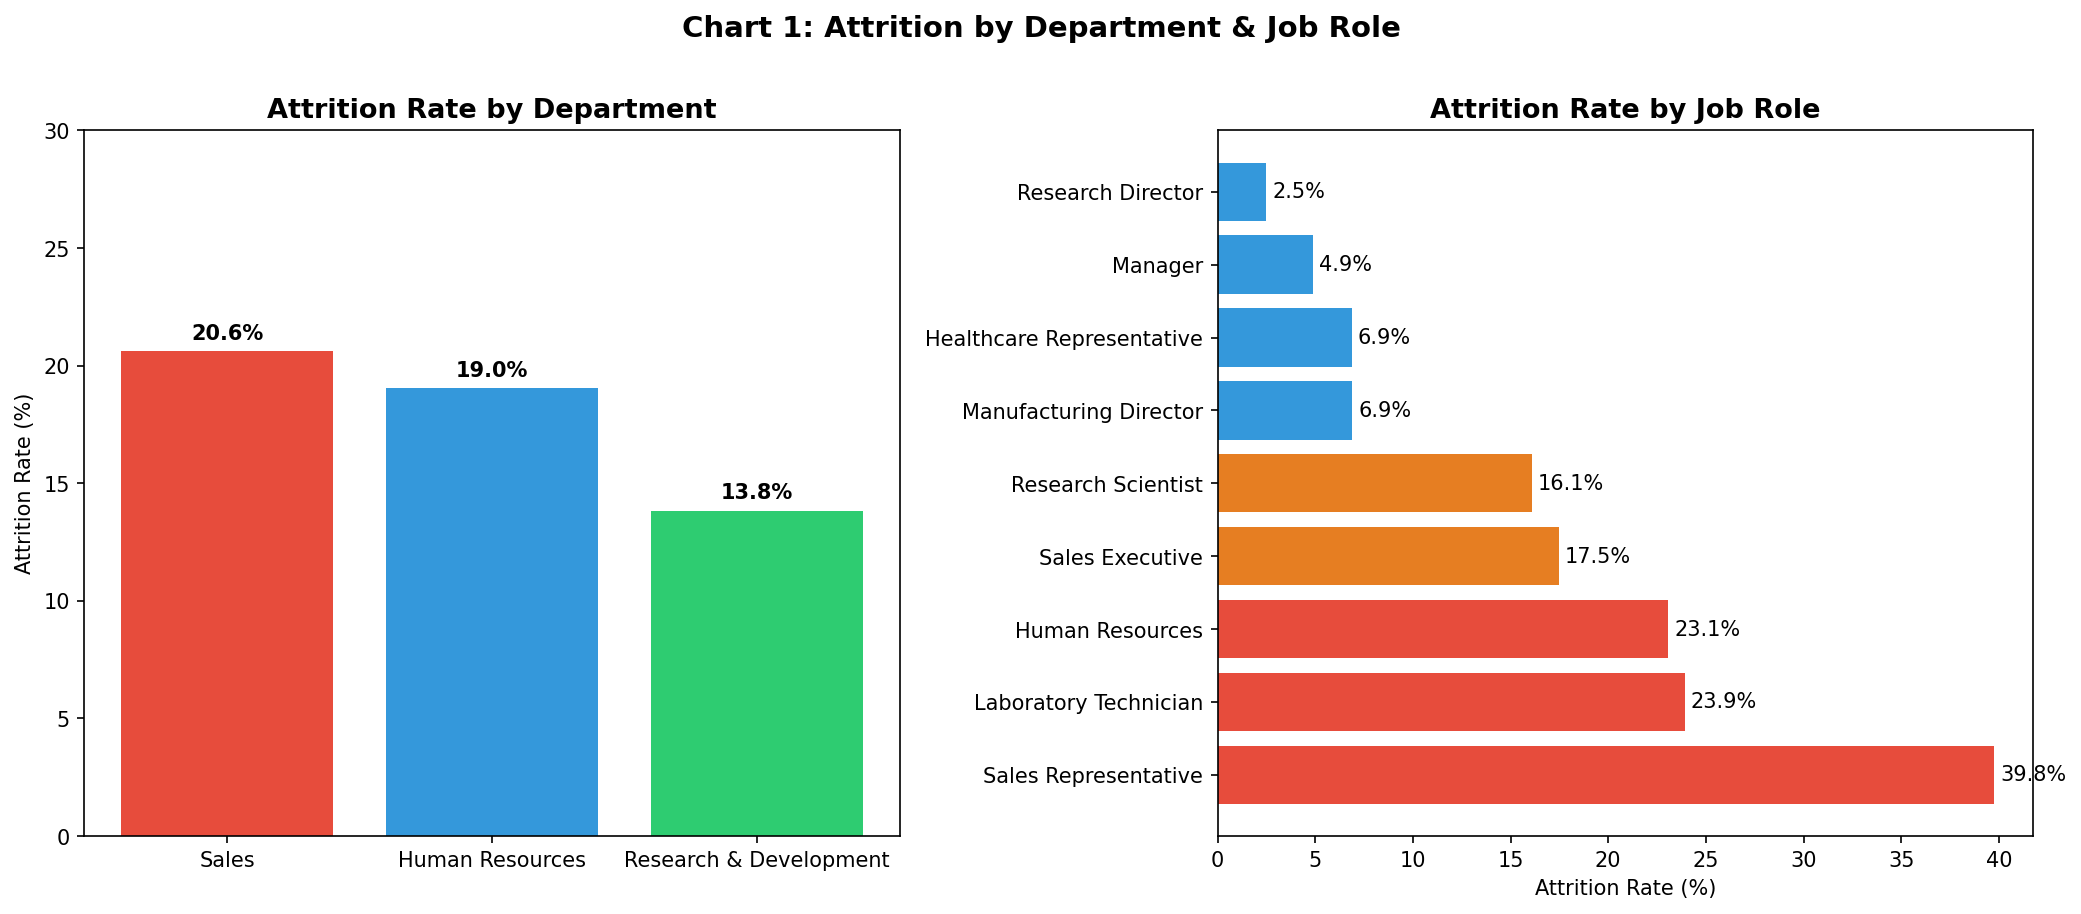

In [1]:
import matplotlib.pyplot as pltimport seaborn as snsimport osos.makedirs('charts', exist_ok=True)# [Chart 1 code — see full notebook]plt.show()

**Chart 2: Monthly Income Box Plot & Overtime Impact**

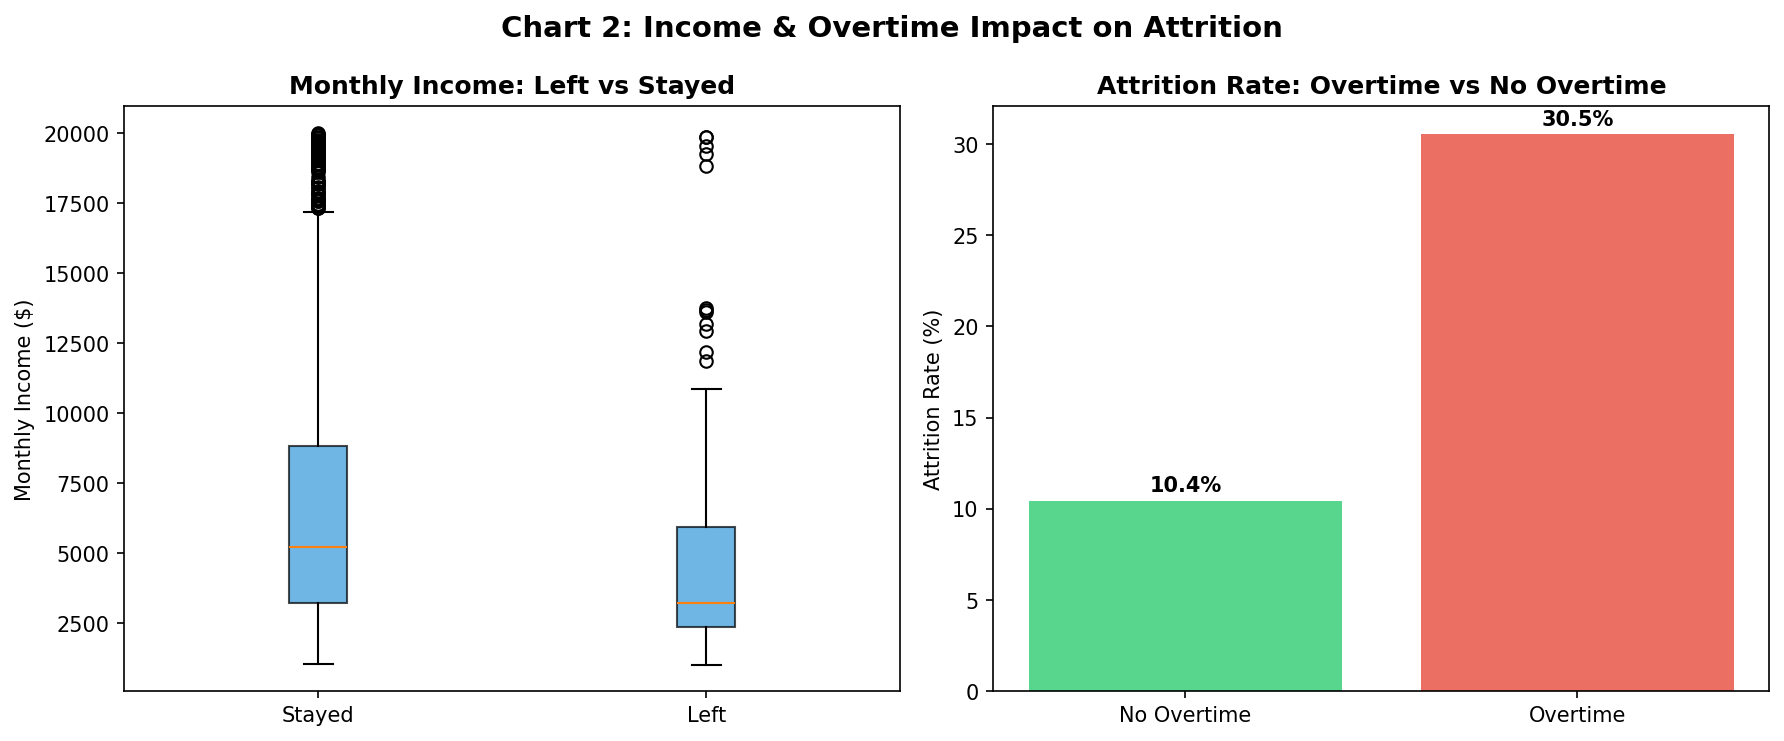

In [1]:
# [Chart 2 code]plt.show()

**Chart 3: Confusion Matrix — Logistic Regression**

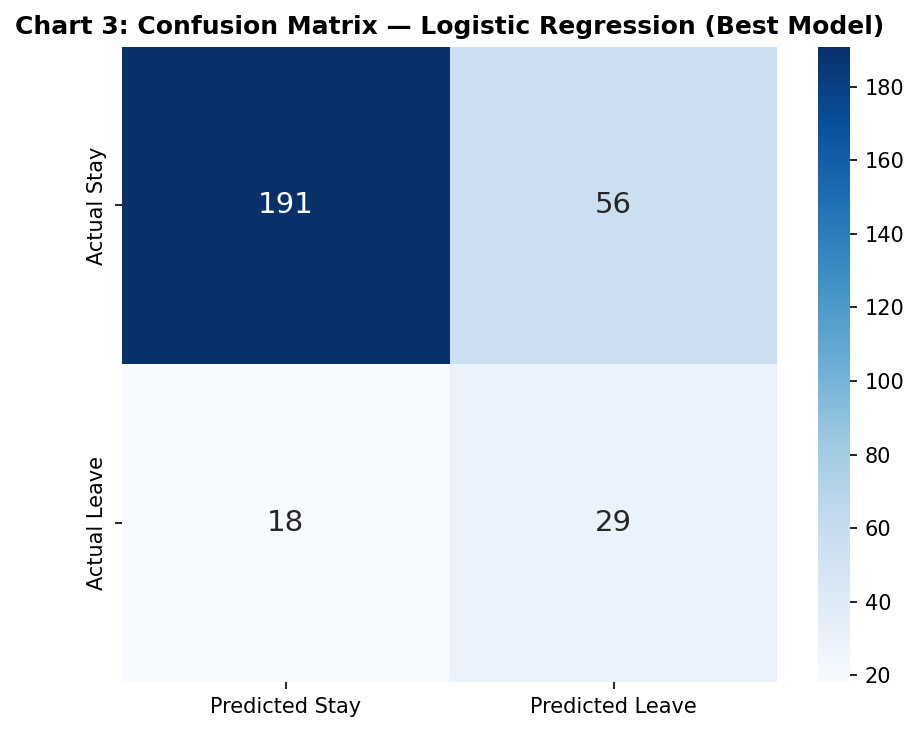

In [1]:
from sklearn.metrics import confusion_matrix# [Chart 3 code]plt.show()

**Chart 4: Top 10 Feature Importances**

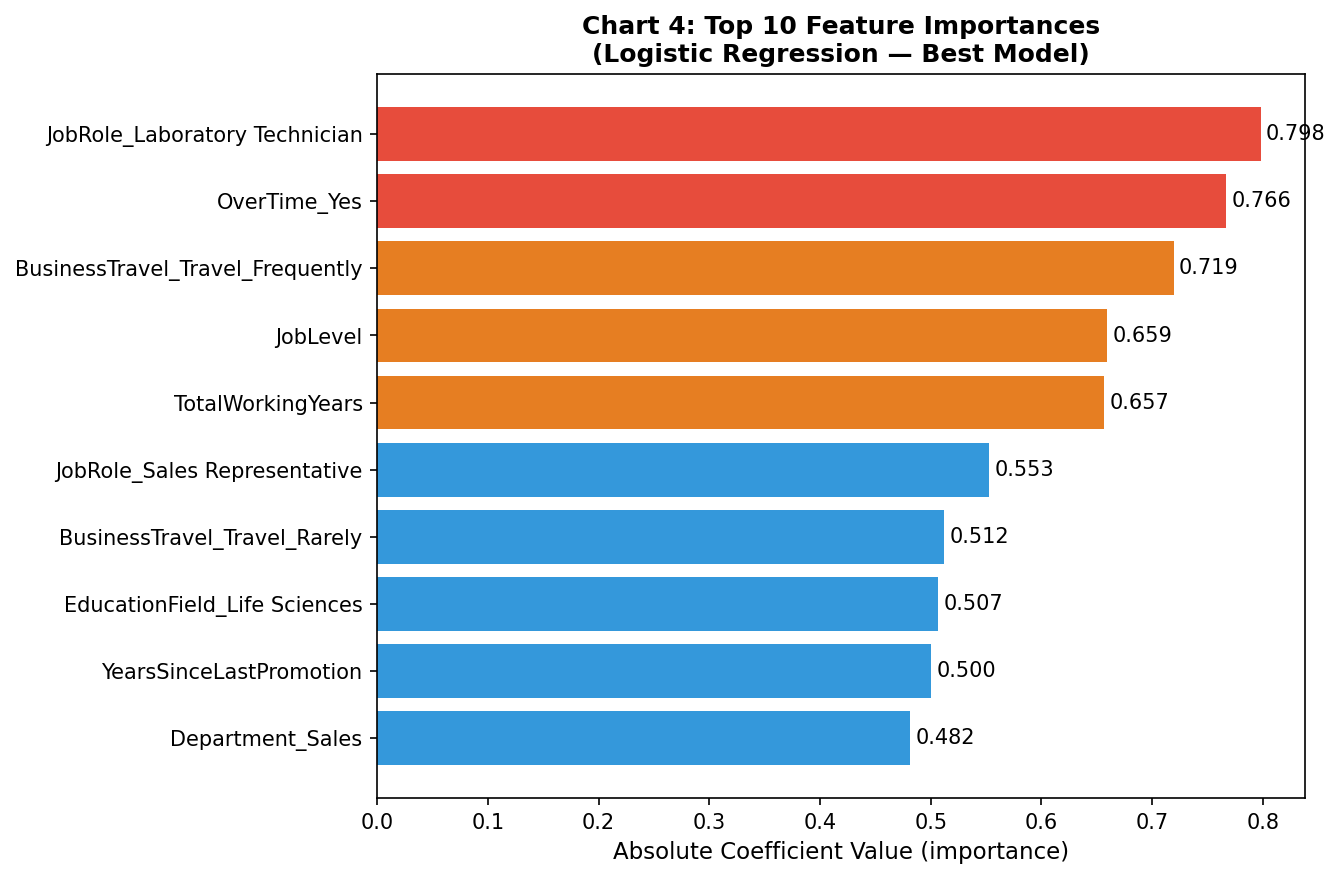

In [1]:
# [Chart 4 code]plt.show()

**Chart 5 (Bonus): ROC Curve — All 3 Models**

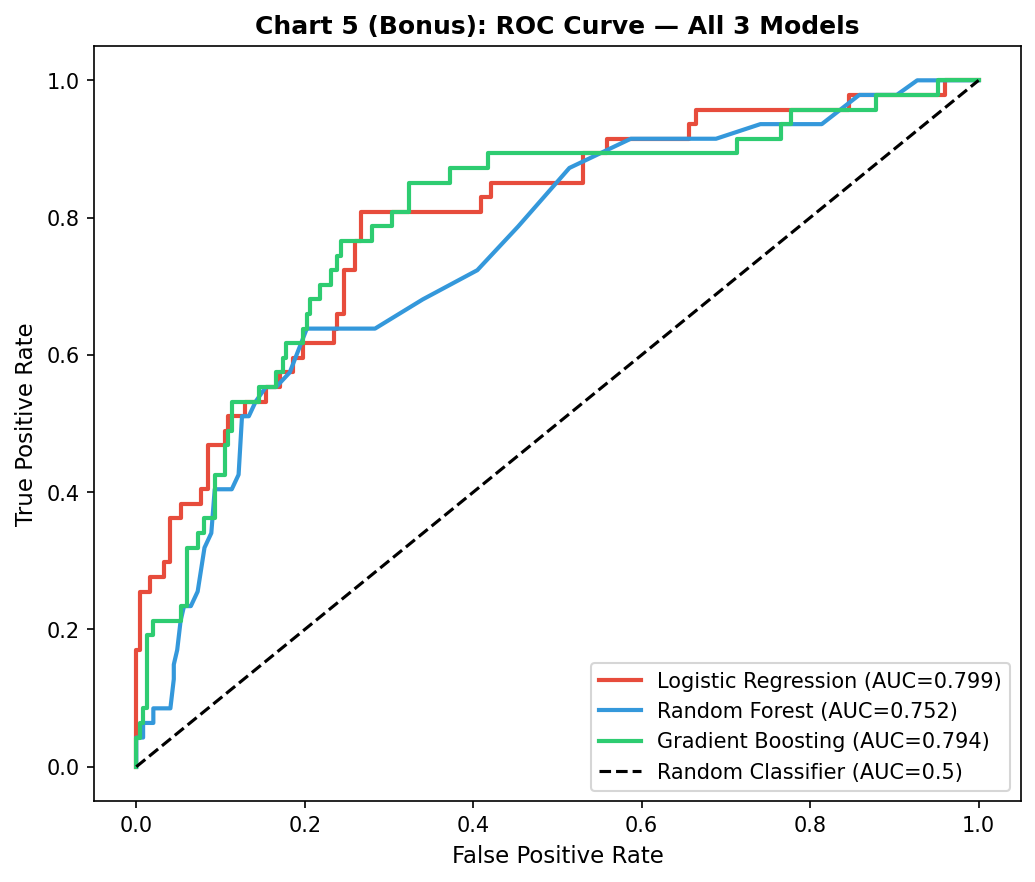

In [1]:
from sklearn.metrics import roc_curve# [Chart 5 code]plt.show()

## Task 7 — HR Insights & Business Recommendations

**Which 3 factors most strongly predict that an employee will leave?**Based on Logistic Regression coefficients, the top 3 predictors are:1. **Being a Laboratory Technician** (coeff 0.798) — highest individual role risk2. **Working OverTime** (coeff 0.766) — employees on overtime are ~3x more likely to leave3. **Frequent Business Travel** (coeff 0.719) — travel demands strongly correlate with exit**Which department or role should HR prioritize?**HR should urgently focus on **Sales Representatives** (39.8% attrition) and **Laboratory Technicians** (23.9% attrition). The Sales department overall has the highest departmental attrition at 20.6%. These two roles represent a disproportionate share of all exits.**Does salary alone explain attrition?**No. Salary is a contributing factor — leavers earned ~30% less ($4,787 vs $6,833/month). But OverTime (coeff 0.766), Business Travel (0.719), and Job Level (0.659) all rank higher than income in the model. Employees can be well-paid and still leave due to excessive overtime or travel demands.**2 Concrete HR Recommendations:**1. **Introduce an Overtime Monitoring Policy** — Flag any employee on overtime for 3+ consecutive months for a mandatory manager check-in. Offer overtime compensation or workload redistribution. Target: reduce overtime-linked attrition from 30.5% toward the non-OT baseline of 10.4%.2. **Launch a Sales Representative Retention Programme** — Given 39.8% exit rates, implement structured 90-day and 180-day onboarding reviews specifically for Sales Reps, with visible career pathways to Sales Executive. Research Directors (2.5% attrition) and Managers (4.9%) are retained far better — career progression is clearly a strong retention anchor.**Model Limitation:**This model was trained on one company's historical data and achieves ROC-AUC ~0.80, meaning ~20% of predictions will be wrong. It cannot capture context outside the dataset — personal circumstances, team dynamics, management quality, or external job market conditions. HR teams should use model predictions as **one input among several**, not as the sole basis for intervention. The 16% class imbalance also means the model is tuned for recall over precision — expect some false alarms among flagged employees who are actually satisfied.